# Orders.csv — General Overview

Quick exploratory look at `orders.csv`: shape, dtypes, missing values, duplicates, and summary stats for key numeric and categorical fields.

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df.shape

(682792, 11)

In [2]:
df.head()

,Order_ID,Customer_iD,Order_weight__g,Shipping_fee_excl__VAT,Total_amount_excl__VAT,Profit_margin,Profit,Shipping_Country,Billing_Country,Order_Date,Timestamp
0,155464,1000001,NaN,0.0,298.8,0.71,212.148,SE,SE,2019-03-15,17:08
1,187332,1000002,NaN,0.0,298.8,0.71,212.148,SE,SE,2019-05-23,19:38
2,148175,1000003,NaN,0.0,298.8,0.71,212.148,SE,SE,2019-03-03,07:44
3,159362,1000004,NaN,0.0,298.8,0.71,212.148,SE,SE,2019-03-22,20:09
4,187395,1000005,NaN,0.0,298.8,0.71,212.148,SE,SE,2019-05-23,21:26


## Dtypes & basic info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 682792 entries, 0 to 682791
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Order_ID                682792 non-null  int64         
 1   Customer_iD             682792 non-null  int64         
 2   Order_weight__g         578739 non-null  float64       
 3   Shipping_fee_excl__VAT  682792 non-null  float64       
 4   Total_amount_excl__VAT  682792 non-null  float64       
 5   Profit_margin           665916 non-null  float64       
 6   Profit                  665916 non-null  float64       
 7   Shipping_Country        682788 non-null  str           
 8   Billing_Country         682788 non-null  str           
 9   Order_Date              682792 non-null  datetime64[us]
 10  Timestamp               682792 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(2), str(3)
memory usage: 57.3 MB


## Missing values & duplicates

In [4]:
missing = df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(2)
missing

,n_missing,pct_missing
Order_ID,0,0.00
Customer_iD,0,0.00
Order_weight__g,104053,15.24
Shipping_fee_excl__VAT,0,0.00
Total_amount_excl__VAT,0,0.00
Profit_margin,16876,2.47
Profit,16876,2.47
Shipping_Country,4,0.00
Billing_Country,4,0.00
Order_Date,0,0.00


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Order_ID:", df["Order_ID"].duplicated().sum())
print("Unique customers:", df["Customer_iD"].nunique())

Duplicate rows: 0
Duplicate Order_ID: 0
Unique customers: 577950


## Numeric summary

In [6]:
num_cols = ["Order_weight__g", "Shipping_fee_excl__VAT", "Total_amount_excl__VAT", "Profit_margin", "Profit"]
df[num_cols].describe()

,Order_weight__g,Shipping_fee_excl__VAT,Total_amount_excl__VAT,Profit_margin,Profit
count,578739.000000,682792.000000,682792.000000,665916.000000,665916.000000
mean,1052.020609,14.666156,510.792087,0.642023,327.965248
std,1888.586736,21.337535,459.045080,0.089555,296.071651
min,6.000000,0.000000,0.000000,0.420000,0.000000
25%,90.000000,0.000000,262.690000,0.590000,165.107200
50%,192.000000,0.000000,385.500000,0.670000,247.757100
75%,1366.000000,41.802500,596.400000,0.700000,382.338000
max,150000.000000,1828.860000,20921.540000,0.830000,13367.200000


## Categorical breakdown

In [7]:
print("Shipping_Country value counts:")
display(df["Shipping_Country"].value_counts())

print("\nBilling_Country value counts:")
display(df["Billing_Country"].value_counts())

print("\nShipping == Billing country match rate:")
(df["Shipping_Country"] == df["Billing_Country"]).mean()

Shipping_Country value counts:


Shipping_Country
DE    156910
SE    114375
GB     77483
DK     52143
NL     50491
FR     40817
PL     35964
NO     30297
FI     22359
US     21977
AT     18768
IT     16419
ES     16267
CA     10465
BE      7893
IE      6424
CZ       722
CH       522
HU       382
PT       332
JP       328
RO       282
AU       213
EE       173
HR       153
LU       116
SK       105
SI       103
NZ        91
LT        86
LV        78
BG        31
KR        15
AE         4
Name: count, dtype: int64


Billing_Country value counts:


Billing_Country
DE    156910
SE    114374
GB     77482
DK     52144
NL     50491
FR     40819
PL     35964
NO     30296
FI     22361
US     21978
AT     18768
IT     16420
ES     16267
CA     10465
BE      7893
IE      6423
CZ       722
CH       522
HU       382
PT       329
JP       328
RO       282
AU       213
EE       173
HR       153
LU       116
SK       105
SI       103
NZ        91
LT        86
LV        78
BG        31
KR        15
AE         4
Name: count, dtype: int64


Shipping == Billing country match rate:


np.float64(0.9999780313770519)

## Orders over time

In [8]:
print("Date range:", df["Order_Date"].min(), "to", df["Order_Date"].max())

orders_per_month = df.set_index("Order_Date").resample("MS").size()
orders_per_month

Date range: 2018-10-14 00:00:00 to 2020-10-30 00:00:00


Order_Date
2018-10-01     1179
2018-11-01     7301
2018-12-01     7720
2019-01-01    12857
2019-02-01    14566
2019-03-01    15937
2019-04-01    12791
2019-05-01    12634
2019-06-01     9966
2019-07-01    13867
2019-08-01    19699
2019-09-01    20937
2019-10-01    21436
2019-11-01    22909
2019-12-01    24103
2020-01-01    27183
2020-02-01    29165
2020-03-01    32096
2020-04-01    58365
2020-05-01    67299
2020-06-01    49475
2020-07-01    49408
2020-08-01    47686
2020-09-01    47072
2020-10-01    57141
Freq: MS, dtype: int64

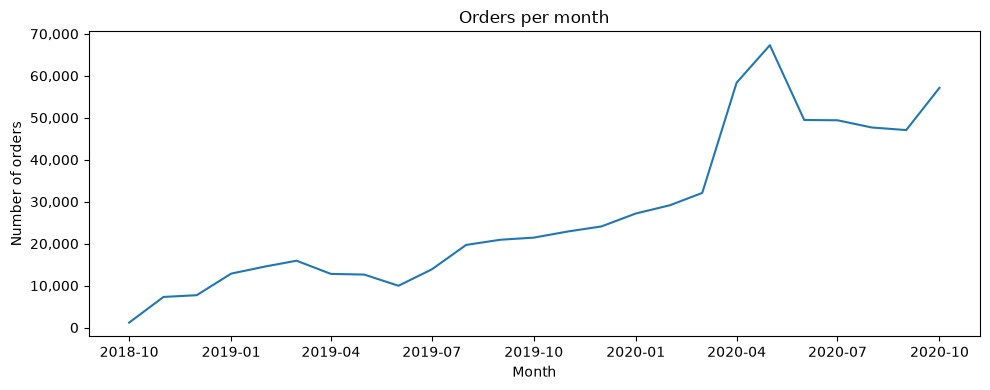

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# No scientific notation / offset text anywhere; big sums get scaled to millions instead.
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x / 1e6:,.0f}")


def set_log_axis_plain(ax, axis="x"):
    """Show plain whole numbers (e.g. 1,000) on a log axis instead of 10^n."""
    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_formatter(PLAIN)
    a.set_minor_formatter(mticker.NullFormatter())


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(orders_per_month.index, orders_per_month.values)
ax.set_title("Orders per month")
ax.set_ylabel("Number of orders")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(PLAIN)
fig.tight_layout()
plt.show()

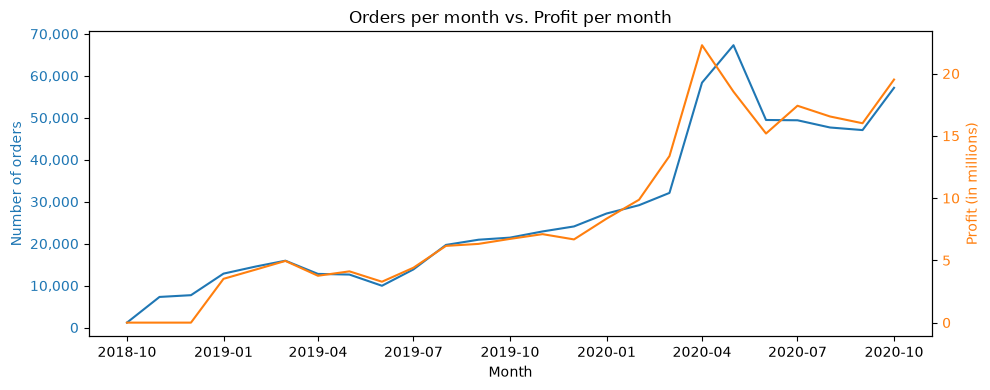

In [10]:
profit_per_month = df.set_index("Order_Date").resample("MS")["Profit"].sum()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(orders_per_month.index, orders_per_month.values, color="tab:blue", label="Orders")
ax1.set_ylabel("Number of orders", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.yaxis.set_major_formatter(PLAIN)
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(profit_per_month.index, profit_per_month.values, color="tab:orange", label="Profit")
ax2.set_ylabel("Profit (in millions)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.yaxis.set_major_formatter(MILLIONS)

plt.title("Orders per month vs. Profit per month")
fig.tight_layout()
plt.show()

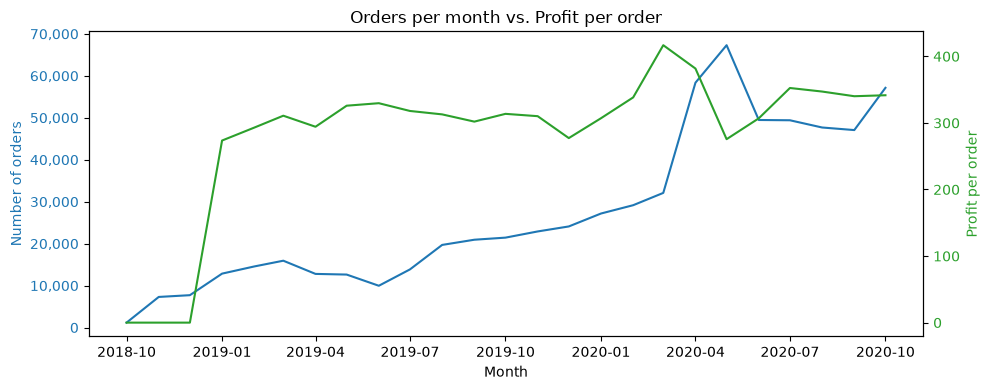

In [11]:
profit_per_order = profit_per_month / orders_per_month

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(orders_per_month.index, orders_per_month.values, color="tab:blue", label="Orders")
ax1.set_ylabel("Number of orders", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.yaxis.set_major_formatter(PLAIN)
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(profit_per_order.index, profit_per_order.values, color="tab:green", label="Profit per order")
ax2.set_ylabel("Profit per order", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.yaxis.set_major_formatter(PLAIN)

plt.title("Orders per month vs. Profit per order")
fig.tight_layout()
plt.show()

## Revenue — last 12 months of data

"Revenue" = `Total_amount_excl__VAT`. Since the dataset ends 2020-10-30, "past 12 months" is taken relative to the latest order date in the data (not today's date).

In [12]:
last_date = df["Order_Date"].max()
start_date = last_date - pd.DateOffset(months=12)

mask = (df["Order_Date"] > start_date) & (df["Order_Date"] <= last_date)
revenue_last_12m = df.loc[mask, "Total_amount_excl__VAT"].sum()
profit_last_12m = df.loc[mask, "Profit"].sum()

print(f"Window: {start_date.date()} (exclusive) to {last_date.date()} (inclusive)")
print(f"Orders in window: {mask.sum():,}")
print(f"Total revenue (excl. VAT): {revenue_last_12m:,.2f}")
print(f"Total profit: {profit_last_12m:,.2f}")

Window: 2019-10-30 (exclusive) to 2020-10-30 (inclusive)
Orders in window: 512,658
Total revenue (excl. VAT): 271,657,789.14
Total profit: 171,121,375.28


## Shipping weight vs. Profit vs. Cost

Sampled scatter of orders (weight on a log x-axis, profit on the y-axis, colored by shipping cost). Rows with missing weight are dropped.

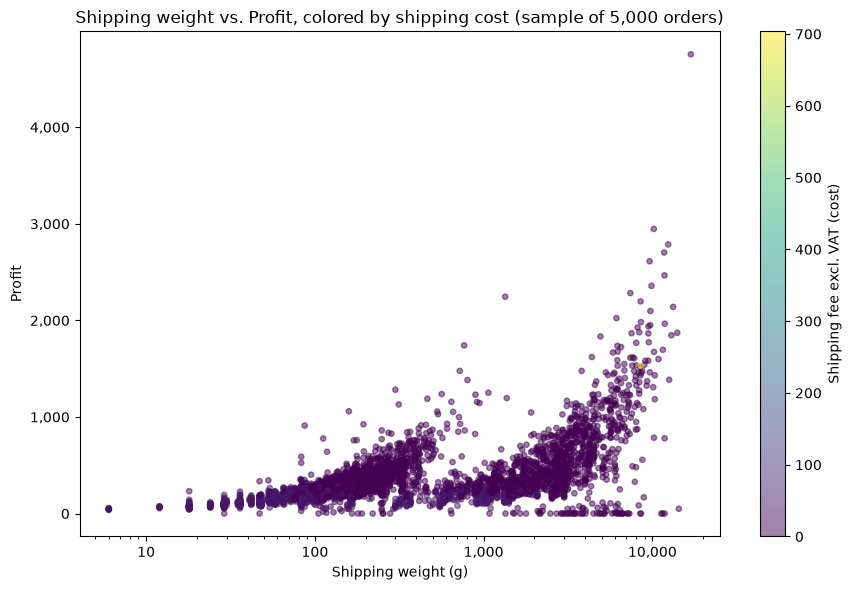

In [13]:
plot_df = df.dropna(subset=["Order_weight__g", "Profit", "Shipping_fee_excl__VAT"])
sample = plot_df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    sample["Order_weight__g"], sample["Profit"],
    c=sample["Shipping_fee_excl__VAT"], cmap="viridis",
    alpha=0.5, s=15,
)
ax.set_xscale("log")
set_log_axis_plain(ax, axis="x")
ax.yaxis.set_major_formatter(PLAIN)
ax.set_xlabel("Shipping weight (g)")
ax.set_ylabel("Profit")
ax.set_title("Shipping weight vs. Profit, colored by shipping cost (sample of 5,000 orders)")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Shipping fee excl. VAT (cost)")
cbar.ax.yaxis.set_major_formatter(PLAIN)
fig.tight_layout()
plt.show()

## Profit per shipping cost vs. weight

"Profit per shipping" = mean profit divided by mean shipping cost, computed within weight deciles. Orders with a zero shipping fee (free shipping) are excluded here so the ratio is defined.

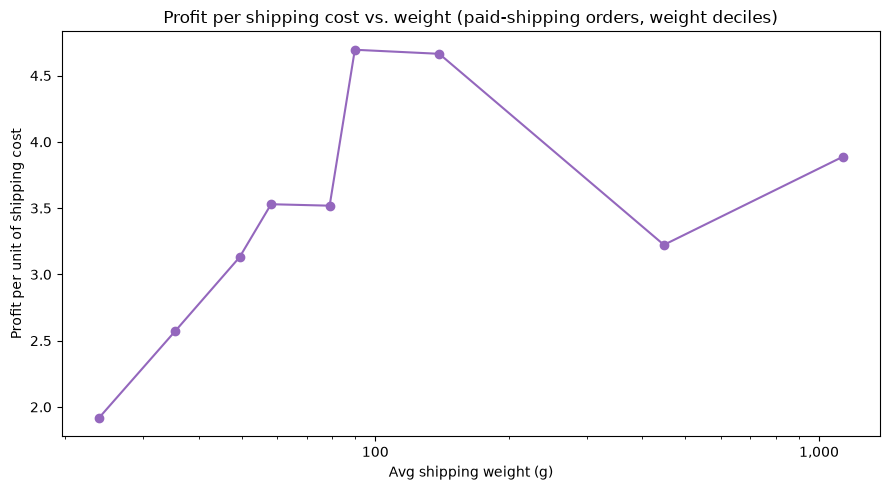

In [14]:
paid = df.dropna(subset=["Order_weight__g", "Profit", "Shipping_fee_excl__VAT"])
paid = paid[paid["Shipping_fee_excl__VAT"] > 0]

weight_bins = pd.qcut(paid["Order_weight__g"], q=10, duplicates="drop")
binned = paid.groupby(weight_bins, observed=True).agg(
    weight=("Order_weight__g", "mean"),
    profit=("Profit", "mean"),
    shipping_fee=("Shipping_fee_excl__VAT", "mean"),
)
binned["profit_per_shipping"] = binned["profit"] / binned["shipping_fee"]
binned = binned.sort_values("weight")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(binned["weight"], binned["profit_per_shipping"], marker="o", color="tab:purple")
ax.set_xscale("log")
set_log_axis_plain(ax, axis="x")
ax.set_xlabel("Avg shipping weight (g)")
ax.set_ylabel("Profit per unit of shipping cost")
ax.set_title("Profit per shipping cost vs. weight (paid-shipping orders, weight deciles)")
fig.tight_layout()
plt.show()

## Top 10 shipping countries

Used as the country set for the charts below.

In [15]:
top10_countries = df["Shipping_Country"].value_counts().head(10).index.tolist()
top10_countries

['DE', 'SE', 'GB', 'DK', 'NL', 'FR', 'PL', 'NO', 'FI', 'US']

## Shipping weight vs. Profit vs. Cost — top 10 countries

Small multiples, one scatter per country (weight log x-axis, profit y-axis, colored by shipping cost, shared color scale). Each panel is sampled to at most 2,000 orders.

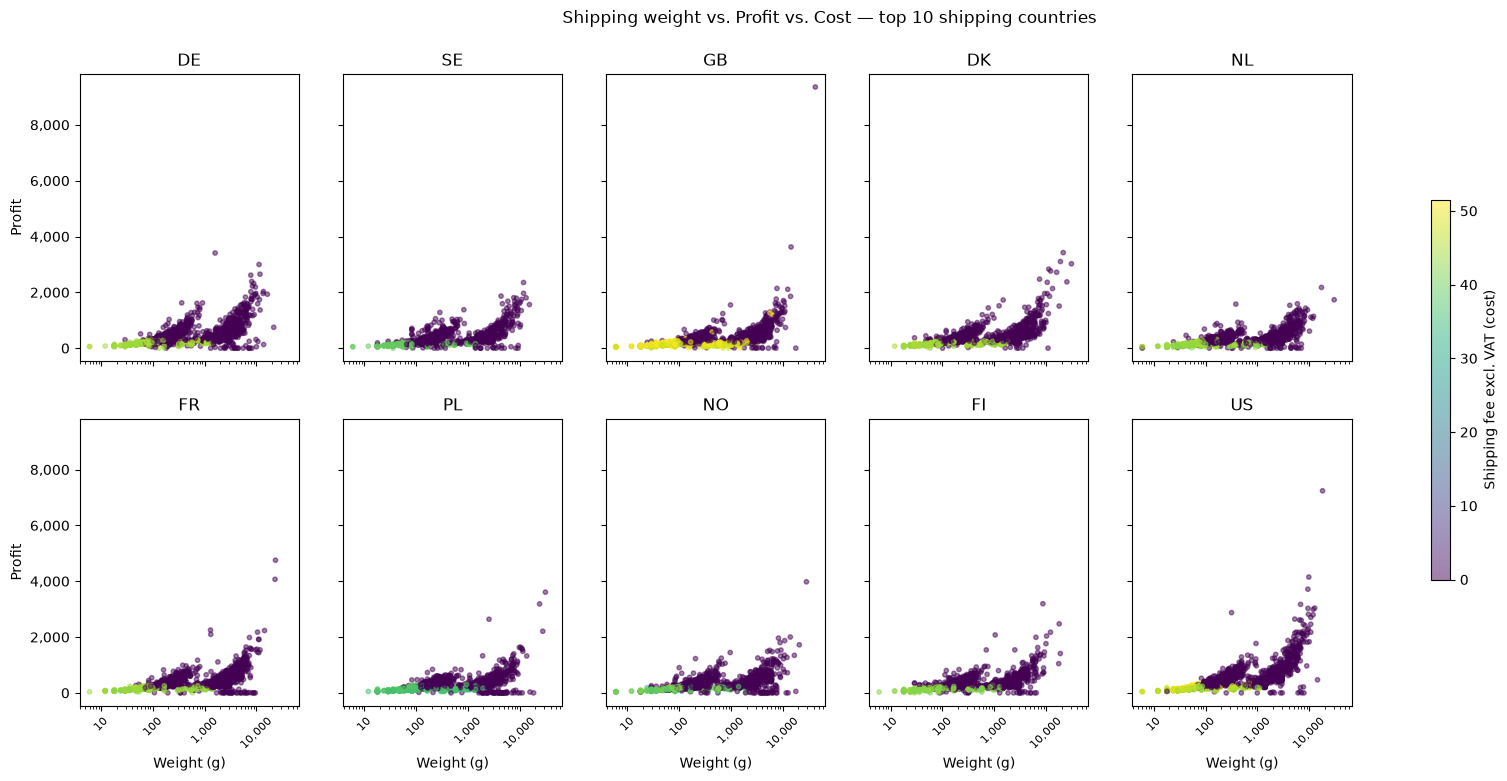

In [16]:
plot_df10 = df[df["Shipping_Country"].isin(top10_countries)].dropna(
    subset=["Order_weight__g", "Profit", "Shipping_fee_excl__VAT"]
)
vmin = plot_df10["Shipping_fee_excl__VAT"].quantile(0.01)
vmax = plot_df10["Shipping_fee_excl__VAT"].quantile(0.99)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
for ax, country in zip(axes.flat, top10_countries):
    sub = plot_df10[plot_df10["Shipping_Country"] == country]
    sub = sub.sample(min(len(sub), 2000), random_state=42)
    sc = ax.scatter(
        sub["Order_weight__g"], sub["Profit"],
        c=sub["Shipping_fee_excl__VAT"], cmap="viridis",
        vmin=vmin, vmax=vmax, alpha=0.5, s=10,
    )
    ax.set_xscale("log")
    set_log_axis_plain(ax, axis="x")
    ax.tick_params(axis="x", labelsize=8, labelrotation=45)
    ax.yaxis.set_major_formatter(PLAIN)
    ax.set_title(country)

for ax in axes[-1]:
    ax.set_xlabel("Weight (g)")
for ax in axes[:, 0]:
    ax.set_ylabel("Profit")

fig.suptitle("Shipping weight vs. Profit vs. Cost — top 10 shipping countries")
fig.subplots_adjust(top=0.9, right=0.92)
cbar = fig.colorbar(sc, ax=axes, shrink=0.6, label="Shipping fee excl. VAT (cost)")
cbar.ax.yaxis.set_major_formatter(PLAIN)
plt.show()

## Profit per shipping cost vs. weight — top 10 countries

Same ratio as above (mean profit / mean shipping cost, paid-shipping orders only), binned into weight quintiles per country, one line per country.

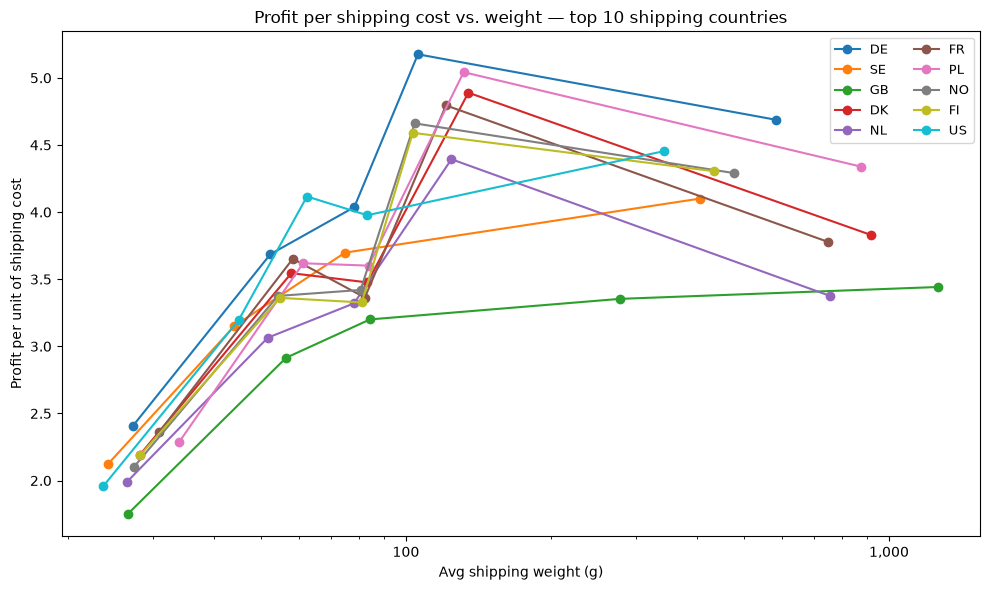

In [17]:
paid10 = df[df["Shipping_Country"].isin(top10_countries)].dropna(
    subset=["Order_weight__g", "Profit", "Shipping_fee_excl__VAT"]
)
paid10 = paid10[paid10["Shipping_fee_excl__VAT"] > 0]

fig, ax = plt.subplots(figsize=(10, 6))
for country in top10_countries:
    sub = paid10[paid10["Shipping_Country"] == country]
    bins = pd.qcut(sub["Order_weight__g"], q=5, duplicates="drop")
    grouped = sub.groupby(bins, observed=True).agg(
        weight=("Order_weight__g", "mean"),
        profit=("Profit", "mean"),
        shipping_fee=("Shipping_fee_excl__VAT", "mean"),
    )
    grouped["profit_per_shipping"] = grouped["profit"] / grouped["shipping_fee"]
    grouped = grouped.sort_values("weight")
    ax.plot(grouped["weight"], grouped["profit_per_shipping"], marker="o", label=country)

ax.set_xscale("log")
set_log_axis_plain(ax, axis="x")
ax.set_xlabel("Avg shipping weight (g)")
ax.set_ylabel("Profit per unit of shipping cost")
ax.set_title("Profit per shipping cost vs. weight — top 10 shipping countries")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

## Profit vs. buying power — top 10 countries

"Buying power" is proxied by GDP per capita, PPP (current international $), fetched live from the World Bank API for 2019 (the most complete calendar year covered by the data, which spans Oct 2018–Oct 2020). Source: [World Bank, indicator NY.GDP.PCAP.PP.CD](https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.CD).

In [18]:
import json
import urllib.request

iso3 = {
    "DE": "DEU", "SE": "SWE", "GB": "GBR", "DK": "DNK", "NL": "NLD",
    "FR": "FRA", "PL": "POL", "NO": "NOR", "FI": "FIN", "US": "USA",
}
codes = [iso3[c] for c in top10_countries]
url = (
    "https://api.worldbank.org/v2/country/" + ";".join(codes)
    + "/indicator/NY.GDP.PCAP.PP.CD?date=2019&format=json&per_page=100"
)

with urllib.request.urlopen(url, timeout=15) as resp:
    payload = json.load(resp)

gdp_ppp = pd.Series(
    {rec["country"]["id"]: rec["value"] for rec in payload[1]},
    name="gdp_per_capita_ppp_2019",
)
gdp_ppp

DE    59310.969397
DK    60594.966400
FI    52276.111572
FR    51130.472314
GB    50493.944190
NL    62345.253847
NO    73630.072186
PL    35882.365507
SE    56909.753156
US    65227.956591
Name: gdp_per_capita_ppp_2019, dtype: float64

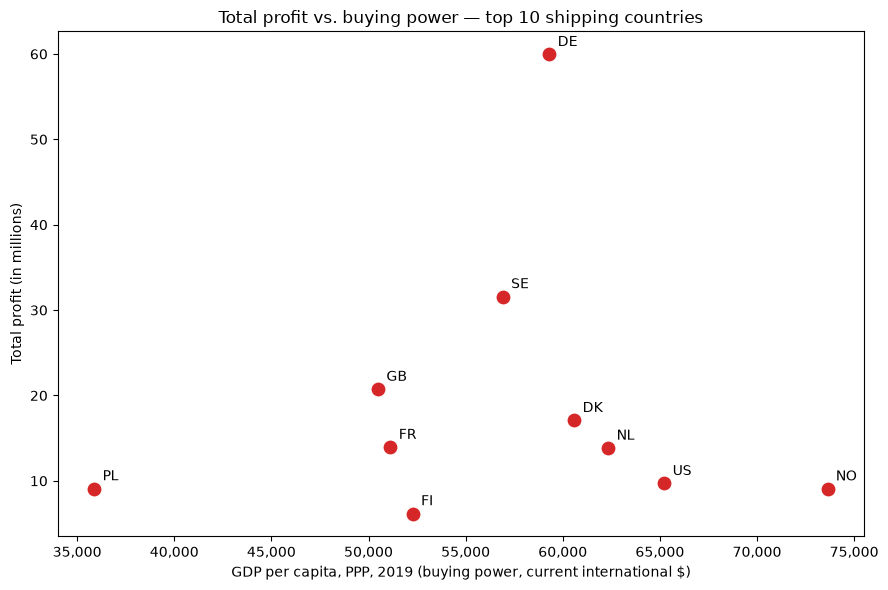

In [19]:
country_profit = df[df["Shipping_Country"].isin(top10_countries)].groupby("Shipping_Country")["Profit"].sum()

summary = pd.DataFrame({
    "total_profit": country_profit,
    "gdp_per_capita_ppp_2019": gdp_ppp,
}).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(summary["gdp_per_capita_ppp_2019"], summary["total_profit"], s=80, color="tab:red")
for country, row in summary.iterrows():
    ax.annotate(
        country, (row["gdp_per_capita_ppp_2019"], row["total_profit"]),
        textcoords="offset points", xytext=(6, 6),
    )

ax.set_xlabel("GDP per capita, PPP, 2019 (buying power, current international $)")
ax.set_ylabel("Total profit (in millions)")
ax.xaxis.set_major_formatter(PLAIN)
ax.yaxis.set_major_formatter(MILLIONS)
ax.set_title("Total profit vs. buying power — top 10 shipping countries")
fig.tight_layout()
plt.show()

## Why do 800–1200g shipments show such low profit?

The earlier weight-vs-profit scatter shows a visible dip in that range. To explain it, split profit into its two drivers: `Profit ≈ Profit_margin × Total_amount_excl__VAT`. If margin is flat across weights, the dip must come from order value, not from costs eating into margin.

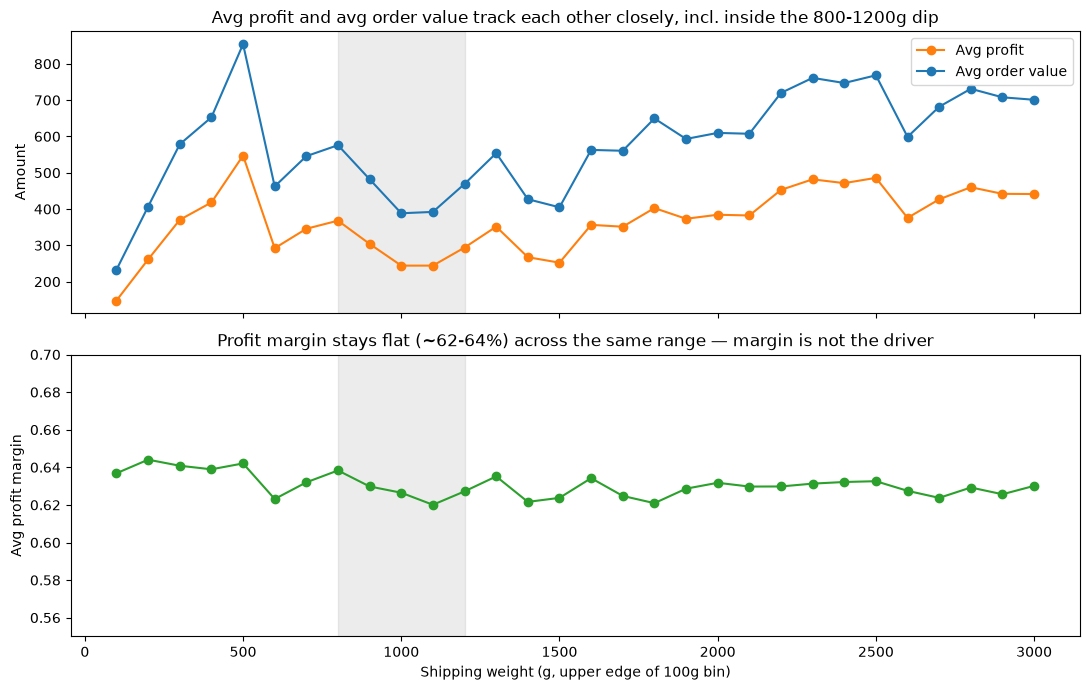

In [20]:
weight_capped = df.dropna(subset=["Order_weight__g", "Profit", "Total_amount_excl__VAT", "Profit_margin"])
weight_capped = weight_capped[weight_capped["Order_weight__g"] <= 3000]

bins_100g = pd.cut(weight_capped["Order_weight__g"], bins=range(0, 3100, 100))
by_bin = weight_capped.groupby(bins_100g, observed=True).agg(
    avg_profit=("Profit", "mean"),
    avg_total=("Total_amount_excl__VAT", "mean"),
    avg_margin=("Profit_margin", "mean"),
)
by_bin.index = by_bin.index.map(lambda iv: int(iv.right))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(by_bin.index, by_bin["avg_profit"], marker="o", color="tab:orange", label="Avg profit")
axes[0].plot(by_bin.index, by_bin["avg_total"], marker="o", color="tab:blue", label="Avg order value")
axes[0].axvspan(800, 1200, color="grey", alpha=0.15)
axes[0].set_ylabel("Amount")
axes[0].yaxis.set_major_formatter(PLAIN)
axes[0].legend()
axes[0].set_title("Avg profit and avg order value track each other closely, incl. inside the 800-1200g dip")

axes[1].plot(by_bin.index, by_bin["avg_margin"], marker="o", color="tab:green")
axes[1].axvspan(800, 1200, color="grey", alpha=0.15)
axes[1].set_ylabel("Avg profit margin")
axes[1].set_xlabel("Shipping weight (g, upper edge of 100g bin)")
axes[1].set_ylim(0.55, 0.70)
axes[1].set_title("Profit margin stays flat (~62-64%) across the same range — margin is not the driver")

fig.tight_layout()
plt.show()

So the dip is a lower-order-value effect, not a lower-margin effect. Next: why is order value lower there? Across the whole dataset, heavier orders are worth more (more/bulkier items) — weight and order value are strongly correlated. Check whether that relationship still holds *inside* the 800–1200g band.

In [21]:
weighted = df.dropna(subset=["Order_weight__g", "Total_amount_excl__VAT"])
band = weighted[(weighted["Order_weight__g"] >= 800) & (weighted["Order_weight__g"] <= 1200)]

corr_overall = weighted["Order_weight__g"].corr(weighted["Total_amount_excl__VAT"])
corr_band = band["Order_weight__g"].corr(band["Total_amount_excl__VAT"])
print(f"Correlation(weight, order value) — whole dataset: {corr_overall:.2f}")
print(f"Correlation(weight, order value) — 800-1200g band only: {corr_band:.2f}")
print()

top_weight = band["Order_weight__g"].value_counts().idxmax()
top_weight_share = band["Order_weight__g"].value_counts(normalize=True).max() * 100
print(f"Single most common weight in the band: {top_weight:g} g ({top_weight_share:.1f}% of all 800-1200g orders)")

single_sku = band[band["Order_weight__g"] == top_weight]
print(f"That single weight value alone: n={len(single_sku):,}, "
      f"avg order value={single_sku['Total_amount_excl__VAT'].mean():,.2f}, "
      f"avg profit={single_sku['Profit'].mean():,.2f}, "
      f"avg margin={single_sku['Profit_margin'].mean():.2f}, "
      f"free-shipping rate={(single_sku['Shipping_fee_excl__VAT'] == 0).mean() * 100:.1f}%")
print(f"Whole-dataset averages: avg order value={weighted['Total_amount_excl__VAT'].mean():,.2f}, "
      f"avg profit={df['Profit'].mean():,.2f}")

Correlation(weight, order value) — whole dataset: 0.72
Correlation(weight, order value) — 800-1200g band only: 0.02

Single most common weight in the band: 1158 g (18.0% of all 800-1200g orders)
That single weight value alone: n=4,585, avg order value=457.60, avg profit=284.83, avg margin=0.62, free-shipping rate=99.9%
Whole-dataset averages: avg order value=523.06, avg profit=327.97


**Takeaway:** Across the full dataset, weight and order value move together (r ≈ 0.72) — heavier orders tend to be worth more, which is what pulls profit up as weight increases elsewhere in the chart. Inside the 800–1200g band that relationship nearly disappears (r ≈ 0.02): weight stops predicting value.

That's because this band isn't a random slice of orders of varying size — it's dominated by one recurring, fixed-weight item (~1,158g accounts for roughly 18% of every order in the band on its own), almost always shipped free, at a fairly fixed and moderate price point. Its average order value and profit sit well below the dataset-wide average, so it drags the whole band down.

**Bottom line:** the 800–1200g band isn't inherently less profitable *per gram* or *per shipment* — margins there are normal. It just contains a heavier concentration of one standardized, moderately-priced product than the surrounding weight ranges, which are dominated instead by higher-value, more variable multi-item orders. This is a product-mix effect, not a shipping-cost or pricing problem.

## Why does every top-10 country chart show the same "break" in the middle?

The small-multiples scatter and the per-country line chart above both show the same shape in *every* one of the 10 countries: profit rises with weight up to roughly 400-600g, dips through roughly 800-1600g, then resumes rising. That dip is the same 800-1200g effect explained above — it isn't country-specific.

It shows up everywhere because the dominant ~1,158g product isn't sold in just one market: it's sold in every country in roughly the same proportion as that country's overall order volume (its country mix in the earlier check was DE 21%, GB 15.5%, SE 10.6%, NL 8%, DK 6.2%, FR/NO/PL ~5.7% each, FI 3.6% — almost identical to the dataset's overall country shares). Since it's a large, evenly-spread share of orders everywhere, it pulls down the average profit in that weight band for every country's chart the same way, producing the same visual "break" in each panel.

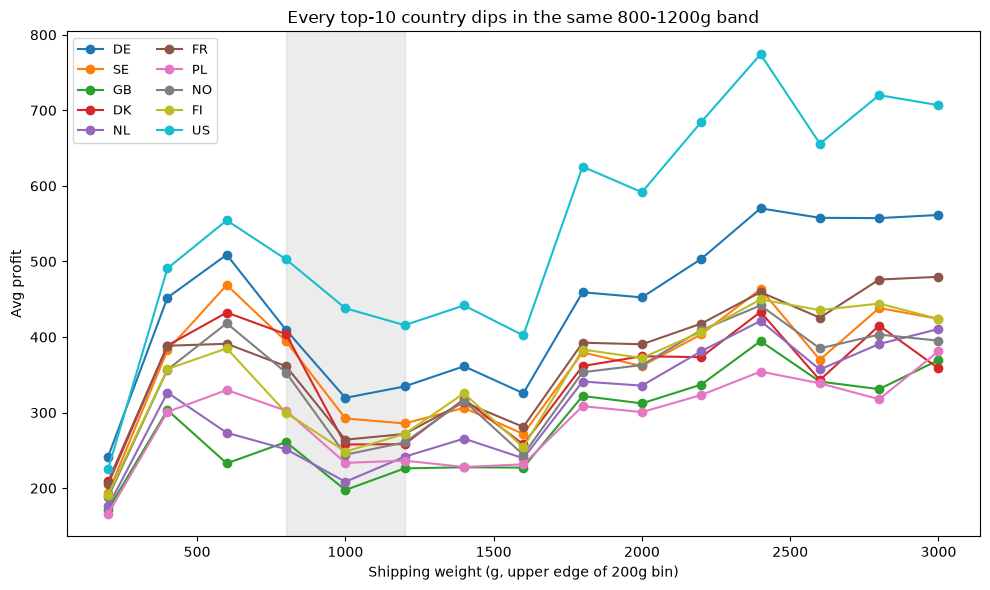

In [22]:
by_country = df[df["Shipping_Country"].isin(top10_countries)].dropna(
    subset=["Order_weight__g", "Profit"]
)
by_country = by_country[by_country["Order_weight__g"] <= 3000]

bins_200g = pd.cut(by_country["Order_weight__g"], bins=range(0, 3100, 200))
pivot = by_country.groupby(["Shipping_Country", bins_200g], observed=True)["Profit"].mean()
pivot = pivot.unstack("Shipping_Country")[top10_countries]
pivot.index = pivot.index.map(lambda iv: int(iv.right))

fig, ax = plt.subplots(figsize=(10, 6))
for country in top10_countries:
    ax.plot(pivot.index, pivot[country], marker="o", label=country)

ax.axvspan(800, 1200, color="grey", alpha=0.15)
ax.set_xlabel("Shipping weight (g, upper edge of 200g bin)")
ax.set_ylabel("Avg profit")
ax.yaxis.set_major_formatter(PLAIN)
ax.set_title('Every top-10 country dips in the same 800-1200g band')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()